In [1]:
import os
from typing import Any, List, Tuple

import matplotlib.pyplot as plt
from alphagenome.data import genome
from alphagenome.visualization import plot_components
from alphagenome_research.io import fasta
from alphagenome_research.model import dna_model
from alphagenome_research.model.dna_model import OrganismSettings
from alphagenome_research.model.metadata import metadata


class VariantGenerator:
    """A generator that automatically produces genome.Variant objects based on a specified Interval and list of modification sites."""

    def __init__(self, fasta_path: str):
        # Reuse fasta_extractor logic
        self._fasta_extractor = fasta.FastaExtractor(fasta_path)

    def generate_variant(
        self,
        interval: genome.Interval,
        sites_to_modify: List[Tuple[int, int]],
        relative_coords: bool = False,
    ) -> genome.Variant:
        """
        Generates a genome.Variant object with reference bases replaced by an equal length of 'A's.

        :param interval: genome.Interval object, representing the reference background interval.
        :param sites_to_modify: List of intervals to modify, e.g., [(1000, 1030), (2000, 2060)].
        :param relative_coords: If True, input coordinates are relative offsets to interval.start;
                                If False, input coordinates are absolute chromosomal physical coordinates.
        :return: genome.Variant object.
        """
        if not sites_to_modify:
            raise ValueError("Modification sites list 'sites_to_modify' cannot be empty.")

        # 1. Coordinate conversion and boundary validation
        absolute_sites = []
        for start, end in sites_to_modify:
            if relative_coords:
                abs_start = interval.start + start
                abs_end = interval.start + end
            else:
                abs_start = start
                abs_end = end

            # Check if site exceeds boundaries
            if abs_start < interval.start or abs_end > interval.end:
                raise ValueError(
                    f"Site ({abs_start}, {abs_end}) exceeds the interval boundaries "
                    f"[{interval.start}, {interval.end}]."
                )
            if abs_start >= abs_end:
                raise ValueError(f"Invalid site interval: ({abs_start}, {abs_end}), start must be less than end.")

            absolute_sites.append((abs_start, abs_end))

        # 2. Sort and merge overlapping or adjacent sites (to prevent slice replacement index errors)
        absolute_sites.sort(key=lambda x: x[0])
        merged_sites = []
        for current in absolute_sites:
            if not merged_sites:
                merged_sites.append(current)
            else:
                prev_start, prev_end = merged_sites[-1]
                curr_start, curr_end = current
                if curr_start <= prev_end:  # Overlapping or directly adjacent
                    merged_sites[-1] = (prev_start, max(prev_end, curr_end))
                else:
                    merged_sites.append(current)

        # 3. Determine start and end points for the unified Variant (start of first site to end of last site)
        var_start = merged_sites[0][0]
        var_end = merged_sites[-1][1]

        # 4. Construct a larger Interval to extract reference bases
        var_interval = genome.Interval(
            chromosome=interval.chromosome,
            start=var_start,
            end=var_end
        )

        # 5. Extract the complete reference sequence
        ref_seq = self._fasta_extractor.extract(var_interval)

        # 6. Generate alternate_bases replaced with 'A's
        # Convert to list for easy slice replacement at specific indices
        alt_seq_list = list(ref_seq)

        for site_start, site_end in merged_sites:
            # Calculate relative offset within the unified Variant sequence
            rel_start = site_start - var_start
            rel_end = site_end - var_start

            # Replace with equal length of 'A'
            length = rel_end - rel_start
            alt_seq_list[rel_start:rel_end] = ['A'] * length

        alternate_bases = "".join(alt_seq_list)

        # 7. Construct and return the Variant object
        return genome.Variant(
            chromosome=interval.chromosome,
            position=var_start,
            reference_bases=ref_seq,
            alternate_bases=alternate_bases
        )


CHECKPOINT_PATH = '/lustre/home/yywu/alphagenome_research/weights/alphagenome-all-folds'

LOCAL_BASE = '/lustre/home/yywu/alphagenome_research/reference'

custom_settings = {
    dna_model.Organism.HOMO_SAPIENS: OrganismSettings(
        fasta_path=f'{LOCAL_BASE}/GRCh38.p13.genome.fa',
        gtf_feather_path=f'{LOCAL_BASE}/gencode.v46.annotation.gtf.gz.feather',
        pas_feather_path=f'{LOCAL_BASE}/polyadb_human_v3_exon3_contiguous_gtfv46.feather',
        splice_site_starts_feather_path=f'{LOCAL_BASE}/gencode.v46.splice_sites_starts.feather',
        splice_site_ends_feather_path=f'{LOCAL_BASE}/gencode.v46.splice_sites_ends.feather',
    )
}

# 3. Load model
model = dna_model.create(
    CHECKPOINT_PATH,
    organism_settings=custom_settings,
    device=None
)

/flashfs1/work/yywu/miniconda3/envs/alphagenome/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
I0000 00:00:1790676659.188782   29885 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/flashfs1/work/yywu/miniconda3/envs/alphagenome/lib/python3.11/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
I0000 00:00:1790676660.820887   29885 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation or

In [8]:
import numpy as np
import pandas as pd

interval = genome.Interval(chromosome='chr6', start=135102054, end=135331430)

A = (135110738, 135110844)
B = (135148394, 135148529)
C = (135322399, 135322765)
TSS = (135181370, 135181529)


sites_absolutes = [[TSS], [A], [B], [C], [A,B], [A, C], [B, C], [A, B, C]]

total_rna = []
polya_rna = []

for sites_absolute in sites_absolutes:

    generator = VariantGenerator(fasta_path=f'{LOCAL_BASE}/GRCh38.p13.genome.fa')
    variant = generator.generate_variant(
        interval=interval,
        sites_to_modify=sites_absolute,
        relative_coords=False 
    )
    
    
    outputs = model.predict_variant(
        interval=interval,
        variant=variant,
        organism=dna_model.Organism.HOMO_SAPIENS,
        ontology_terms=['EFO:0002067'],
        requested_outputs=[dna_model.OutputType.RNA_SEQ],
    )
    
    interval_myb= genome.Interval(chromosome='chr6', start=135181308, end=135219172)
    
    ALT = outputs.alternate.rna_seq.slice_by_interval(interval_myb)
    REF = outputs.reference.rna_seq.slice_by_interval(interval_myb)
    
    ref_sum = np.sum(REF.values, axis=0)  
    alt_sum = np.sum(ALT.values, axis=0)
    
    eps = 1e-6
    log2_fc_total = np.log2((alt_sum + eps) / (ref_sum + eps))

    total_rna.append(log2_fc_total[1])
    polya_rna.append(log2_fc_total[0])

In [9]:
outputs.reference.rna_seq.metadata

,name,strand,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,gtex_tissue,data_source,endedness,genetically_modified,nonzero_mean
119,EFO:0002067 polyA plus RNA-seq,+,polyA plus RNA-seq,EFO:0002067,K562,cell_line,adult,,encode,paired,False,0.129111
120,EFO:0002067 total RNA-seq,+,total RNA-seq,EFO:0002067,K562,cell_line,adult,,encode,paired,False,0.098649
390,EFO:0002067 polyA plus RNA-seq,-,polyA plus RNA-seq,EFO:0002067,K562,cell_line,adult,,encode,paired,False,0.129111
391,EFO:0002067 total RNA-seq,-,total RNA-seq,EFO:0002067,K562,cell_line,adult,,encode,paired,False,0.098649
571,EFO:0002067 polyA plus RNA-seq,.,polyA plus RNA-seq,EFO:0002067,K562,cell_line,adult,,encode,paired,False,0.240826


In [10]:
outputs.alternate.rna_seq.metadata

,name,strand,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,gtex_tissue,data_source,endedness,genetically_modified,nonzero_mean
119,EFO:0002067 polyA plus RNA-seq,+,polyA plus RNA-seq,EFO:0002067,K562,cell_line,adult,,encode,paired,False,0.129111
120,EFO:0002067 total RNA-seq,+,total RNA-seq,EFO:0002067,K562,cell_line,adult,,encode,paired,False,0.098649
390,EFO:0002067 polyA plus RNA-seq,-,polyA plus RNA-seq,EFO:0002067,K562,cell_line,adult,,encode,paired,False,0.129111
391,EFO:0002067 total RNA-seq,-,total RNA-seq,EFO:0002067,K562,cell_line,adult,,encode,paired,False,0.098649
571,EFO:0002067 polyA plus RNA-seq,.,polyA plus RNA-seq,EFO:0002067,K562,cell_line,adult,,encode,paired,False,0.240826


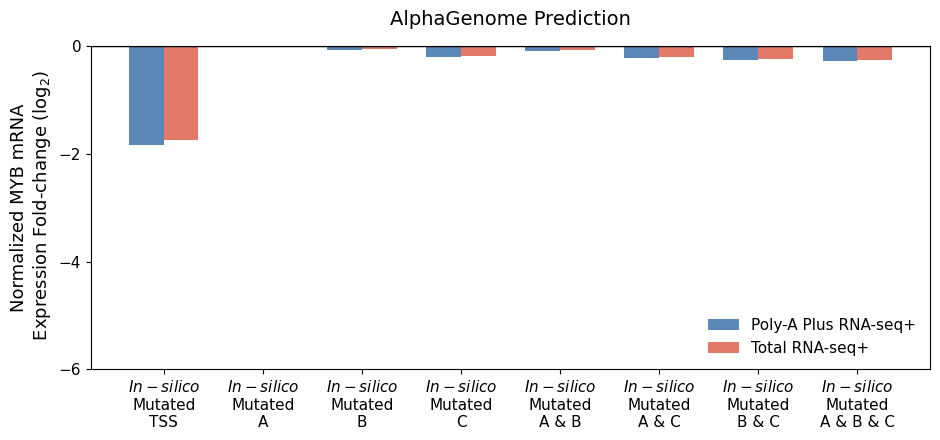

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

categories = ['$\mathit{In-silico}$\nMutated\nTSS', '$\mathit{In-silico}$\nMutated\nA', '$\mathit{In-silico}$\nMutated\nB', 
              '$\mathit{In-silico}$\nMutated\nC', '$\mathit{In-silico}$\nMutated\nA & B', 
              '$\mathit{In-silico}$\nMutated\nA & C', '$\mathit{In-silico}$\nMutated\nB & C', 
              '$\mathit{In-silico}$\nMutated\nA & B & C']


fig, ax = plt.subplots(figsize=(9.5, 4.5))

x = np.arange(len(categories))  
width = 0.35  
rects1 = ax.bar(
    x - width / 2,
    total_rna,
    width,
    label='Poly-A Plus RNA-seq+',
    color='#4A7BB0',  # 经典雅致蓝
    edgecolor='none',
    alpha=0.9,
)

rects2 = ax.bar(
    x + width / 2,
    polya_rna,
    width,
    label='Total RNA-seq+',
    color='#E16B5A',  # 珊瑚暖红
    edgecolor='none',
    alpha=0.9,
)

ax.axhline(0, color='black', linewidth=1, linestyle='-')


ax.set_axisbelow(True)  


ax.set_ylabel('Normalized MYB mRNA\n Expression Fold-change (log$_2$)', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11, fontweight='medium')
ax.tick_params(axis='both', labelsize=11)

ax.legend(frameon=False, fontsize=11, loc='lower right')


ax.set_ylim(-6.0, 0.0)
ax.set_yticks(range(-6, 1, 2))

plt.title(
    r'AlphaGenome Prediction',
    fontsize=14,
    pad=15,
)
plt.tight_layout()

# plt.savefig(
#     'alphagenome_paired_barchart.png', dpi=300, bbox_inches='tight'
# )
plt.show()

/tmp/ipykernel_29885/4232859547.py:37: UserWarning: 
The palette list has fewer values (1) than needed (8) and will cycle, which may produce an uninterpretable plot.
  sns.stripplot(


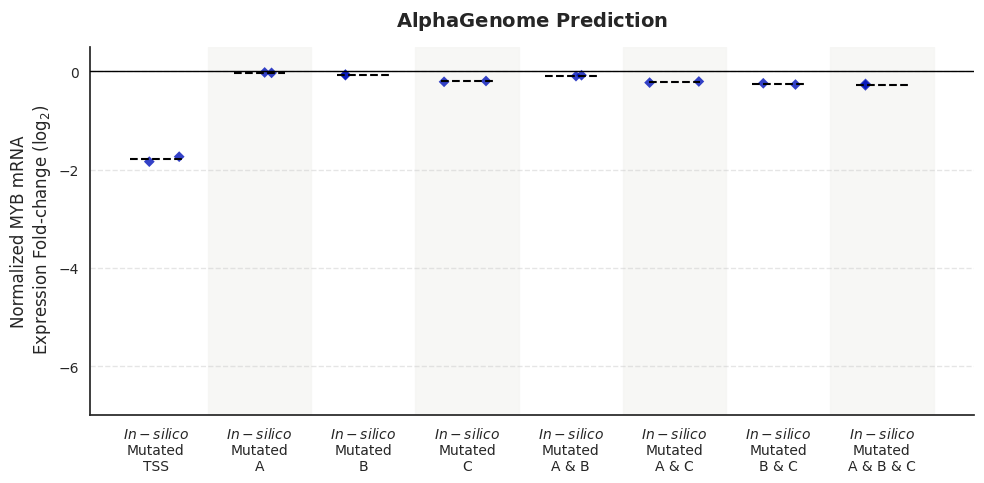

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style='white', font='sans-serif')

categories = [
    '$\mathit{In-silico}$\nMutated\nTSS',
    '$\mathit{In-silico}$\nMutated\nA',
    '$\mathit{In-silico}$\nMutated\nB',
    '$\mathit{In-silico}$\nMutated\nC',
    '$\mathit{In-silico}$\nMutated\nA & B',
    '$\mathit{In-silico}$\nMutated\nA & C',
    '$\mathit{In-silico}$\nMutated\nB & C',
    '$\mathit{In-silico}$\nMutated\nA & B & C',
]

alphagenome_data = [
    [t, p]
    for t, p in zip(total_rna, polya_rna)
]
np.random.seed(42)


fig, ax = plt.subplots(figsize=(10, 5))


def draw_background(ax, num_categories, bg_color='#F5F5F3'):
    for i in range(num_categories):
        if i % 2 == 1:
            ax.axvspan(i - 0.5, i + 0.5, color=bg_color, zorder=0, alpha=0.8)



draw_background(ax, len(categories))

sns.stripplot(
    data=alphagenome_data,
    jitter=0.25,
    palette=['#0012b9'],
    marker='D',
    size=5.5,
    ax=ax,
    zorder=2,
    alpha=0.8,
)

for i, d in enumerate(alphagenome_data):
    mean_val = np.mean(d)
    ax.hlines(
        mean_val,
        i - 0.25,
        i + 0.25,
        colors='black',
        linestyles='--',
        linewidth=1.5,
        zorder=3,
    )

ax.axhline(0, color='black', linewidth=1, linestyle='-', zorder=4)
ax.grid(axis='y', linestyle='--', alpha=0.5, color='#CCCCCC', zorder=1)

ax.set_ylabel(
    'Normalized MYB mRNA\n Expression Fold-change (log$_2$)',
    fontsize=12,
    fontweight='medium',
)
ax.set_xticks(range(len(categories)))
ax.set_xticklabels(categories, fontsize=10)
ax.tick_params(axis='both', labelsize=10, length=4)
ax.set_ylim(-7.0, 0.5)
ax.set_yticks(range(-6, 1, 2))

sns.despine(ax=ax, top=True, right=True)

plt.title(
    r'$\mathbf{AlphaGenome\ Prediction}$',
    fontsize=14,
    pad=15,
)

plt.tight_layout()

# 保存图片
# plt.savefig('alphagenome_stripplot.png', dpi=300, bbox_inches='tight')

plt.show()